# Sync behavioral and imaging data

Todo:
* Load in behav data (uvr expt)
* load in img data (pickle file)
* create df with the florescence data (each col is a roi) from pickle file DF_G
* modify findimgframetimes to use fpv from pickle
* then run combinImagingAndPosDf to sync data

## Imports

In [207]:
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
import numpy as np
import pandas as pd

from unityvr.preproc import logproc as lp
from unityvr.analysis import posAnalysis, align2img
from gulp2p import utils as utils
from gulp2p import ImagingPreProc as iPP
from gulp2p import ROIs as ROIs

## Select data

In [208]:
BHV_DATA_FOLDER = Path(r'Z:\FlyVR\FlyVR data\Kerstin')
OUTPUT_FOLDER = Path(r"C:\Users\ahshenas\Desktop\live fly analysis")

In [209]:
img_file = Path(utils.loadFileNames(single_file=True, title="Select raw imaging data"))
# img_pickle = Path(utils.loadFileNames(single_file=True, title="Select preprocessed imaging data"))
img_pickle = img_file.with_name(img_file.stem+"_DF.p")
# behavior_data = utils.get_bhv_path(img_file, BHV_DATA_FOLDER)
behavior_data = Path(utils.loadFileNames(single_file=True, title="Select behavioral data"))
# img_pickle = Path(r"Z:\GULP\sample\DNa02_tdt+7b_closed loop_4x_00001_DF.p")
# behavior_data = Path(r"Z:\GULP\sample\Log_2023-10-16_16-44-42.json")

## Load data

### Load behavioral data

In [210]:
# uvr.psDf starts with columns: frame, time, dt, x, y, angle, dx, dy, dxattempt, dyattempt
uvr = lp.constructUnityVRexperiment(str(behavior_data.parent), behavior_data.name)

correcting for Unity angle convention.


In [211]:
uvr.metadata

{'expid': 'testExp',
 'experiment': 'test experiment',
 'genotype': 'testGenotype',
 'sex': 'NA',
 'flyid': 'NA',
 'trial': 'trial0-48-00',
 'date': '2023-12-07',
 'time': '10-48-00',
 'ballRad': 0.04699999839067459,
 'setFrameRate': 120,
 'notes': 'NA',
 'angle_convention': 'right-handed'}

In [212]:
posAnalysis.computeVelocities(uvr.posDf) # Adds columns: vT, vR, vT_filt, vR_filt
posAnalysis.position(uvr, derive=True) # Adds columns: ds, s, dTh, radangle
uvr.posDf.head()

,frame,time,dt,x,y,angle,dx,dy,dxattempt,dyattempt,vT,vR,vT_filt,vR_filt,ds,s,dTh,radangle
0,1.0,0.000000,0.020000,0.000010,0.000017,359.990716,0.000010,1.681613e-05,0.000010,1.681613e-05,0.000000,0.000000,0.036650,-0.100398,0.000020,0.000020,0.000000,-0.000162
1,2.0,0.020000,0.020000,0.000010,0.000017,359.990716,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,-0.074342,0.223231,0.000000,0.000020,0.000000,-0.000162
2,3.0,0.021353,0.001353,0.000010,0.000017,359.990716,0.000000,0.000000e+00,0.000000,0.000000e+00,0.131301,-0.020049,0.064734,0.011803,0.000000,0.000020,0.000000,-0.000162
3,4.0,0.033413,0.012060,0.000039,0.000038,359.950617,0.000029,2.117671e-05,0.000029,2.117671e-05,0.048430,-0.045801,0.325116,-0.397555,0.000036,0.000055,-0.040099,-0.000862
4,5.0,0.037600,0.004186,0.000125,0.000039,359.899114,0.000086,8.538690e-07,0.000086,8.538690e-07,0.815026,-0.805528,0.515459,-0.379697,0.000086,0.000141,-0.051504,-0.001761


### Load Imaging data

In [213]:
# Load in pickle file from img processsing with rois and df/f's 
# Create dataframe with a column for each roi and df/f each frame along the rows 
with open(img_pickle, 'rb') as pkl:
    exptDat = pickle.load(pkl)

In [214]:
exptDat.keys()

dict_keys(['trialName', 'fpv', 'meanMIP_G', 'ROIOutlines', 'allROIs', 'rawF_G', 'DF_G'])

In [215]:
exptDat['DF_G'].shape

(2350, 15)

In [216]:
# Create dataframe to store df/f's
imgDat = pd.DataFrame(exptDat['DF_G']).add_prefix('roi')

In [217]:
imgDat

,roi0,roi1,roi2,roi3,roi4,roi5,roi6,roi7,roi8,roi9,roi10,roi11,roi12,roi13,roi14
0,0.312517,0.174598,0.327795,0.418634,0.259811,0.484543,0.883487,0.048000,1.202552,NaN,NaN,NaN,NaN,NaN,NaN
1,0.651457,0.175838,-0.022269,0.216366,0.458704,0.929417,1.960595,0.391309,1.731457,NaN,NaN,NaN,NaN,NaN,NaN
2,0.530337,0.229918,0.149726,0.146338,0.528745,0.639508,1.909934,1.023857,1.797341,NaN,NaN,NaN,NaN,NaN,NaN
3,0.527381,0.119106,0.148661,0.155658,0.441425,0.829765,1.642253,0.119890,1.450991,NaN,NaN,NaN,NaN,NaN,NaN
4,0.742090,0.065474,0.164791,0.341222,0.679803,0.981986,1.843159,0.635795,1.417133,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2345,-0.095745,0.174943,0.054172,0.109352,-0.080866,0.033034,0.305449,0.344113,0.540963,NaN,NaN,NaN,NaN,NaN,NaN
2346,-0.089938,0.326435,0.225730,0.090165,-0.175141,0.120859,0.720760,0.230321,0.097616,NaN,NaN,NaN,NaN,NaN,NaN
2347,0.304014,0.119795,0.114290,0.121066,-0.145672,-0.011305,0.005543,0.140357,0.343767,NaN,NaN,NaN,NaN,NaN,NaN
2348,0.373077,0.059515,0.101704,0.006623,-0.002837,-0.008339,0.867665,0.133942,0.354290,NaN,NaN,NaN,NaN,NaN,NaN


## Syncronize data

In [218]:
# use combineImagingAndPosDf to sync data
#   need to modify findimgframetimes to use fpv from pickle

[imgInd, volFramePos] = align2img.findImgFrameTimes(uvr, fpv=exptDat.get('fpv'))

In [219]:
expDf = align2img.combineImagingAndPosDf(imgDat, uvr.posDf, volFramePos)
exptDat['expDf'] = expDf

Truncated fictrac recording. Difference in length: 30
posDf did not contain tortuosity, curvature, voltes or stitched positions
posDf did not contain flight
posDf did not contain clipped


### Save data to pickle

In [220]:
# Save next to preprocessed img data?
outfile = img_pickle.with_stem(exptDat['trialName'])
with open(outfile, 'wb') as file:
    pickle.dump(exptDat, file)

In [221]:
expDf

,roi0,roi1,roi2,roi3,roi4,roi5,roi6,roi7,roi8,roi9,...,vT,vR,vTfilt,vRfilt,s,ds,dx,dy,flight,clipped
0,0.312517,0.174598,0.327795,0.418634,0.259811,0.484543,0.883487,0.048000,1.202552,NaN,...,0.000000,0.000000,-0.074342,0.223231,0.000020,0.000020,0.000010,0.000017,0.0,0.0
1,0.651457,0.175838,-0.022269,0.216366,0.458704,0.929417,1.960595,0.391309,1.731457,NaN,...,0.519554,0.139669,0.499060,0.027744,0.010399,0.010379,-0.000904,-0.000442,0.0,0.0
2,0.530337,0.229918,0.149726,0.146338,0.528745,0.639508,1.909934,1.023857,1.797341,NaN,...,0.177552,0.141017,0.243582,0.145547,0.016192,0.005793,0.000302,-0.000284,0.0,0.0
3,0.527381,0.119106,0.148661,0.155658,0.441425,0.829765,1.642253,0.119890,1.450991,NaN,...,0.656904,0.642646,0.467437,0.376371,0.024586,0.008394,0.000321,-0.000056,0.0,0.0
4,0.742090,0.065474,0.164791,0.341222,0.679803,0.981986,1.843159,0.635795,1.417133,NaN,...,0.000000,0.000000,0.019429,0.016580,0.025666,0.001080,-0.000184,-0.000318,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2315,0.647776,0.688459,0.350191,0.356103,-0.101840,-0.141320,1.152329,0.911847,1.344844,NaN,...,0.181299,-0.039142,0.094931,0.009508,15.529912,0.007940,0.000549,0.000511,0.0,0.0
2316,0.361826,0.143115,0.243570,0.250320,0.155339,0.171797,1.298218,0.670620,1.239612,NaN,...,0.534375,-0.160028,0.406406,-0.069527,15.534925,0.005013,-0.000199,0.000448,0.0,0.0
2317,0.498190,0.240941,0.273385,0.227897,0.112738,0.131388,1.439461,0.353022,2.688153,NaN,...,0.036816,-0.061051,0.127033,0.003003,15.537437,0.002512,-0.000061,-0.000460,0.0,0.0
2318,0.753912,0.259266,0.243168,0.235189,-0.037523,0.275045,0.759373,0.238213,1.127974,NaN,...,0.207910,-0.023595,0.118444,-0.017524,15.543087,0.005650,0.000747,-0.000418,0.0,0.0


## Plot simple analysis

### Functions

In [222]:
def get_num_rois(df):
    count = 0
    for col in df.columns:
        if (col[:3] == "roi"):
            count += 1
    return count

In [223]:
fm_interval = expDf['posTime'].diff().mean() # Seconds per row of df
print(fm_interval)

0.15472003681815713


In [224]:
def shift_elements(arr, num, fill_value=np.nan):
    arr = np.roll(arr,num)
    if num < 0:
        arr[num:] = fill_value
    elif num > 0:
        arr[:num] = fill_value
    return arr

def correlate_with_lag(a, v, lags):
    corrs = []
    for lag in lags:
        # Lag second array
        if lag < 0:
            lagged_a = a[:lag]
            lagged_v = v[-lag:]
        elif lag == 0:
            lagged_a = a
            lagged_v = v
        else:
            lagged_a = a[lag:]
            lagged_v = v[:-lag]

        corr = np.corrcoef(lagged_a, lagged_v)[0,1]
        corrs.append(corr)

    return corrs

In [225]:
# ['trialName', 'fpv', 'meanMIP_G', 'ROIOutlines', 'allROIs', 'rawF_G', 'DF_G']
def plot_roi(trial_dat, panel, title="Protocerebral Bridge\n glomeruli (ROI's)", full_img=False):
    # Get pixel dimensions
    trial_nm = trial_dat.get('trial_nm', trial_dat.get('trialName'))
    # pixel_dims = trial_dat.get('pixel_dims' ,iPP.getPixelDims(trial_nm))
    rois = trial_dat.get('rois', trial_dat.get('allROIs'))
    mean_stack = trial_dat.get('stack_mean', trial_dat.get('meanMIP_G'))

    view_box = iPP.get_bbox(rois, image_shape=mean_stack.shape, scale_factor=1.5)
    panel.imshow(mean_stack)
    panel.axis('off')

    # Draw ROI's
    for j, r in enumerate(rois):
        X_IDX = 0
        Y_IDX = 1
        panel.add_patch(
            Polygon(
                [[pt[Y_IDX], pt[X_IDX]] for pt in r],
                closed=True,
                fill=False,
                edgecolor=(1, 1, 1, 0.5),
                linewidth=0.5
            )
        )
        panel.text(
            r[:, Y_IDX].mean(),
            r[:, X_IDX].mean(),
            str(j + 1),
            dict(ha='center', va='center', fontsize=3.5, color='w'),
        )

    # # Add scale bar
    # x0, x1 = view_box[1]
    # y0, y1 = view_box[0]

    # # Get reasonable scalebar length
    # scale_bar_length = round((x1-x0)*0.2, -1)
    # if pixel_dims['width_unit'] == "um":
    #     scale_bar_unit = r"$\mu m$"
    # else:
    #     scale_bar_unit = pixel_dims['width_unit']

    # scale_bar_margin = (x1-x0)*0.1
    # scale_bar_x = x1 - scale_bar_margin
    # scale_bar_y = y1 - scale_bar_margin
    # scale_bar_width = scale_bar_length / float(pixel_dims['pixel_width'])
    # scale_bar_height = (y1 - y0) * 0.0005
    # scale_bar = Rectangle([scale_bar_x, scale_bar_y],
    #                       -1 * scale_bar_width,
    #                       -1 * scale_bar_height,
    #                       color='white',
    #                       fill=True)
    # panel.add_patch(scale_bar)

    # labelpad = (y1 - y0) * 0.001
    # scale_bar_text_x = scale_bar_x - scale_bar_width/2
    # scale_bar_text_y = scale_bar_y - scale_bar_height - labelpad
    # panel.text(scale_bar_text_x, scale_bar_text_y,
    #            f"{scale_bar_length} {scale_bar_unit}",
    #            color='white',
    #            fontsize=5,
    #            ha='center',
    #            va='bottom')

    if not full_img:
        panel.set_xlim(view_box[1])
        panel.set_ylim(np.flip(view_box[0]))
    panel.set_title(title)

### Correlation Plot

[0.01869701711928207, 0.013992639701149107, 0.008930051590446594, 0.01768265377999682, 0.020381406194691802, 0.00046621195506596426, 0.023660793489935356, 0.006585019290419896, -0.0019034910369494697, 0.0032874194518202294, -0.009217100230594423, 0.02726774290271635, 0.0034972941632944346, 0.022190089311255944, 0.015445728400654795, 0.009572397155732625, 0.028340782708424564, -0.023496430741128848, 0.021911785913767745, 0.015226075356648067, 0.02392085525017426, 0.00943892182336655, 0.011448719829306888, 0.01726047412283824, 0.0004683191510496409, 0.013320382862772108, 0.007075467293896455, 0.027326369283728436, -0.005369750714058559, 0.005418660745834, 0.0067773831072767445, 0.0025945839508764103, 0.009716966390983902, -0.020247801059502024, 0.02768180990530652, 0.0140529921817785, 0.031848115093408944, -0.027546176821293775, 0.018555968133253237, -0.0070904500855708185, 0.025000452973368722, 0.024813063700734432, 0.026152034740758053, 0.022636383494555056, 0.004275797933089208, 0.007

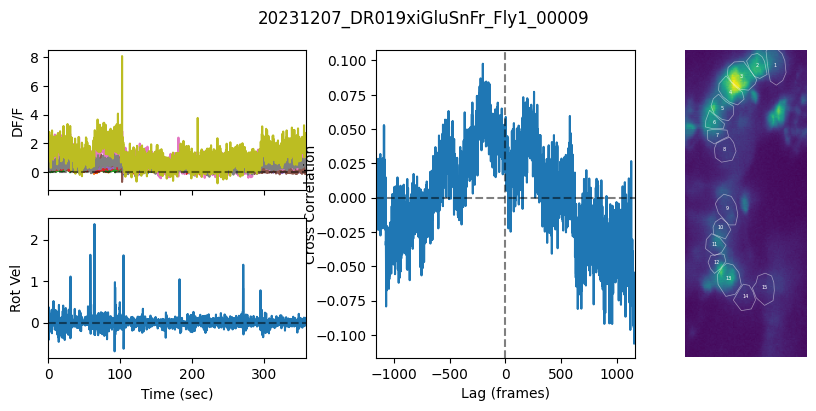

In [226]:
mosaic = [['img', '.', 'corr', 'rois'],
          ['bhv', '.', 'corr', 'rois']]
plots = ['img', 'bhv', 'corr']
fig, axd = plt.subplot_mosaic(mosaic, figsize=(10, 4), width_ratios=[1,0.01,1,0.6])

# Plot DF/F and Rot Vel
for i in range(get_num_rois(expDf)):
    axd['img'].plot(expDf['posTime'], expDf[f'roi{i}'])
axd['bhv'].plot(expDf['posTime'], expDf['vRfilt'])

# Cross correlation
a = expDf['roi0']
v = expDf['vRfilt']
lags = range(-1*len(a)//2, len(a)//2+1)
cross_correlation = correlate_with_lag(a, v, lags)
print(cross_correlation)
axd['corr'].plot(lags, cross_correlation)
# Add vertical line at x=0
axd['corr'].axvline(x=0, color='black', linestyle='--', zorder=2, alpha=0.5)

# Plot horizonal line at y=0
for plot in plots:
    axd[plot].axhline(y=0, color='black', linestyle='--', zorder=2, alpha=0.5)

# Set xlim
for plot in ['img', 'bhv']:
    axd[plot].set_xlim([round(expDf.iloc[0]['posTime']), expDf.iloc[-1]['posTime']])
axd['corr'].set_xlim([lags[0], lags[-1]])

# axd['corr'].set_xticklabels([ frame * expDf['posTime'].diff().mean() for frame in axd['corr'].get_xticks()])
# xticks = [lag for lag in np.arange(-len(a)//2, len(a)//2+1)*fm_interval if round(lag, 0)%20 ==0]
# xticklabels = [f'{tick*fm_interval:3.0f}' for tick in xticks]
# axd['corr'].set_xticks(xticks, xticklabels)

# Plot rois
plot_roi(exptDat, axd['rois'], title="")


axd['img'].set_xticklabels([])

axd['img'].set_ylabel("DF/F")
axd['bhv'].set_ylabel("Rot Vel")
axd['bhv'].set_xlabel("Time (sec)")
axd['corr'].set_ylabel("Cross Correlation", labelpad=-2)
axd['corr'].set_xlabel("Lag (frames)")

fig.suptitle(exptDat.get('trialName'))

# Print peak correlation
peak_corr_lag = lags[np.argmax(cross_correlation)]
print(f'Peak correlation at {peak_corr_lag:+} frames of lag ({peak_corr_lag * fm_interval:+} seconds)')

fig.savefig(Path(OUTPUT_FOLDER, exptDat['trialName']).with_suffix(".png"), dpi=600)

### Head direction plot

[0.01869701711928207, 0.013992639701149107, 0.008930051590446594, 0.01768265377999682, 0.020381406194691802, 0.00046621195506596426, 0.023660793489935356, 0.006585019290419896, -0.0019034910369494697, 0.0032874194518202294, -0.009217100230594423, 0.02726774290271635, 0.0034972941632944346, 0.022190089311255944, 0.015445728400654795, 0.009572397155732625, 0.028340782708424564, -0.023496430741128848, 0.021911785913767745, 0.015226075356648067, 0.02392085525017426, 0.00943892182336655, 0.011448719829306888, 0.01726047412283824, 0.0004683191510496409, 0.013320382862772108, 0.007075467293896455, 0.027326369283728436, -0.005369750714058559, 0.005418660745834, 0.0067773831072767445, 0.0025945839508764103, 0.009716966390983902, -0.020247801059502024, 0.02768180990530652, 0.0140529921817785, 0.031848115093408944, -0.027546176821293775, 0.018555968133253237, -0.0070904500855708185, 0.025000452973368722, 0.024813063700734432, 0.026152034740758053, 0.022636383494555056, 0.004275797933089208, 0.007

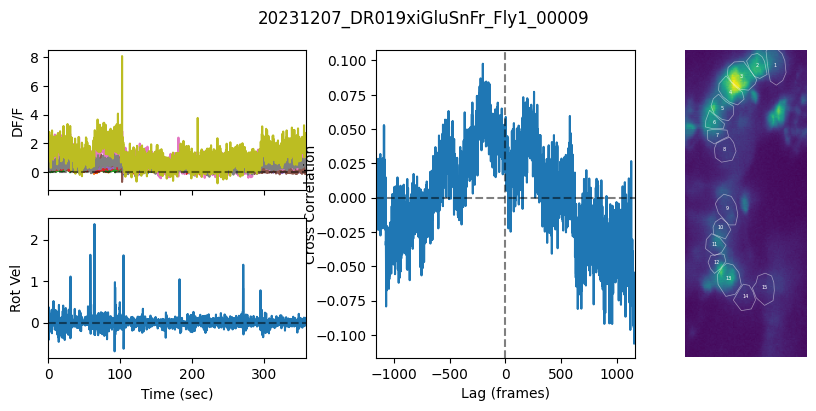

In [227]:
mosaic = [['img', '.', 'corr', 'rois'],
          ['bhv', '.', 'corr', 'rois']]
plots = ['img', 'bhv', 'corr']
fig, axd = plt.subplot_mosaic(mosaic, figsize=(10, 4), width_ratios=[1,0.01,1,0.6])

# Plot DF/F and Rot Vel
for i in range(get_num_rois(expDf)):
    axd['img'].plot(expDf['posTime'], expDf[f'roi{i}'])
axd['bhv'].plot(expDf['posTime'], expDf['vRfilt'])

# Cross correlation
a = expDf['roi0']
v = expDf['vRfilt']
lags = range(-1*len(a)//2, len(a)//2+1)
cross_correlation = correlate_with_lag(a, v, lags)
print(cross_correlation)
axd['corr'].plot(lags, cross_correlation)
# Add vertical line at x=0
axd['corr'].axvline(x=0, color='black', linestyle='--', zorder=2, alpha=0.5)

# Plot horizonal line at y=0
for plot in plots:
    axd[plot].axhline(y=0, color='black', linestyle='--', zorder=2, alpha=0.5)

# Set xlim
for plot in ['img', 'bhv']:
    axd[plot].set_xlim([round(expDf.iloc[0]['posTime']), expDf.iloc[-1]['posTime']])
axd['corr'].set_xlim([lags[0], lags[-1]])

# axd['corr'].set_xticklabels([ frame * expDf['posTime'].diff().mean() for frame in axd['corr'].get_xticks()])
# xticks = [lag for lag in np.arange(-len(a)//2, len(a)//2+1)*fm_interval if round(lag, 0)%20 ==0]
# xticklabels = [f'{tick*fm_interval:3.0f}' for tick in xticks]
# axd['corr'].set_xticks(xticks, xticklabels)

# Plot rois
plot_roi(exptDat, axd['rois'], title="")


axd['img'].set_xticklabels([])

axd['img'].set_ylabel("DF/F")
axd['bhv'].set_ylabel("Rot Vel")
axd['bhv'].set_xlabel("Time (sec)")
axd['corr'].set_ylabel("Cross Correlation", labelpad=-2)
axd['corr'].set_xlabel("Lag (frames)")

fig.suptitle(exptDat.get('trialName'))

# Print peak correlation
peak_corr_lag = lags[np.argmax(cross_correlation)]
print(f'Peak correlation at {peak_corr_lag:+} frames of lag ({peak_corr_lag * fm_interval:+} seconds)')

fig.savefig(Path(OUTPUT_FOLDER, exptDat['trialName']).with_suffix(".png"), dpi=600)

In [228]:
expDf.keys()

Index(['roi0', 'roi1', 'roi2', 'roi3', 'roi4', 'roi5', 'roi6', 'roi7', 'roi8',
       'roi9', 'roi10', 'roi11', 'roi12', 'roi13', 'roi14', 'posTime', 'frame',
       'x', 'y', 'angle', 'vT', 'vR', 'vTfilt', 'vRfilt', 's', 'ds', 'dx',
       'dy', 'flight', 'clipped'],
      dtype='object')

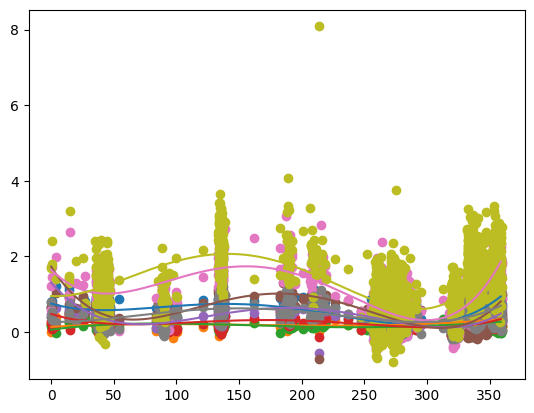

In [229]:
# plt.scatter(expDf['angle'], expDf['vR'])
# plt.scatter(expDf['angle'], expDf['roi0'])
# plt.scatter(expDf['angle'], expDf['roi1'])
roi = 0
for roi in range(15):
    x = expDf['angle']
    y = expDf[f'roi{roi}']
    poly_coefs = np.polyfit(x, y, 4)
    p = np.poly1d(poly_coefs)

    plt.scatter(expDf['angle'], expDf[f'roi{roi}'])
    plt.plot([p(point) for point in np.linspace(0, 360,360)])

    # for i in range(15):
    #     plt.scatter(expDf['angle'], expDf[f'roi{i}'])

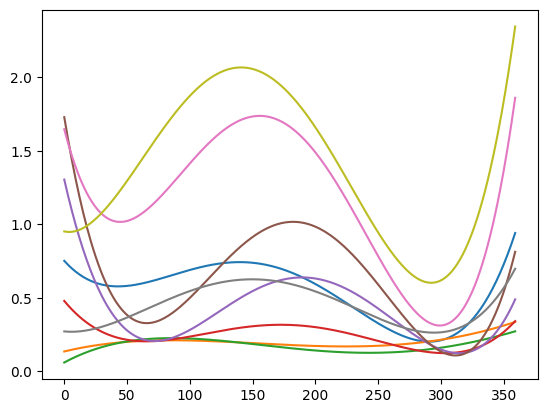

In [230]:
# plt.scatter(expDf['angle'], expDf['vR'])
# plt.scatter(expDf['angle'], expDf['roi0'])
# plt.scatter(expDf['angle'], expDf['roi1'])
roi = 0
for roi in range(15):
    x = expDf['angle']
    y = expDf[f'roi{roi}']
    poly_coefs = np.polyfit(x, y, 4)
    p = np.poly1d(poly_coefs)

    # plt.scatter(expDf['angle'], expDf[f'roi{roi}'])
    plt.plot([p(point) for point in np.linspace(0, 360,360)])

    # for i in range(15):
    #     plt.scatter(expDf['angle'], expDf[f'roi{i}'])